In [1]:
%audit off
%flow mode normal

# Dask + TaskVine Map–Combine–Reduce Benchmark

This notebook:

- Generates synthetic input data (CSV/JSON) for a simple map–combine–reduce workflow.
- Runs the workflow either locally or on TaskVine workers.
- Produces summary statistics and simple visualizations (histograms / bar charts).


In [3]:
# Global configuration for the benchmark

# Synthetic data generation
NUM_FILES = 8
RECORDS_PER_FILE = 5_000
GROUPS = ["A", "B", "C", "D"]        # logical groups / keys
RNG_SEED = 42

# Value distribution controls (you can tweak these to see different histograms)
# Example: group-wise mean and stddev
GROUP_MEANS = {
    "A": 10.0,
    "B": 20.0,
    "C": 30.0,
    "D": 40.0,
}
GROUP_STDS = {
    "A": 2.0,
    "B": 4.0,
    "C": 6.0,
    "D": 8.0,
}

# Map–Combine–Reduce structure
COMBINE_WIDTH = 2  # how many map outputs to merge per combine

# IO locations
INPUT_DIR = "data"
OUTPUT_DIR = "results"
OUTPUT_JSON = f"{OUTPUT_DIR}/final_summary.json"

# Execution mode
USE_THREADED_SCHEDULER = False  # True => local threaded scheduler; False => TaskVine (DaskVine)

# TaskVine manager settings (used when USE_THREADED_SCHEDULER is False)
MANAGER_NAME = "dask-taskvine-mapreduce-manager"
MANAGER_PORTS = "9123"   # e.g. "9123" or "9123,9150"

# Plotting options
PLOT_RAW_MEANS_HIST = True
PLOT_GROUP_COUNTS_BAR = True

Error while executing the command:
/bin/sh: /Users/talhaazaz/Documents/DePaul/Research/floability-cli/cctools/distributed_NBRewind/dask-taskvine-mapreduce-benchmark/workflow/vv: No such file or directory

restoring
restoring


In [4]:
from pathlib import Path
from collections import defaultdict
from math import inf
from typing import List, Dict

import json
import csv
import time

import dask
from dask import delayed

import matplotlib.pyplot as plt

# TaskVine compat scheduler
# from ndcctools.taskvine.compat import DaskVine

from taskvine_rewind.dask_executor import DaskVine

# Your synthetic data generator
import generate_input_data


restoring
restoring
Cannot serialize/deserialize object (type: module): cannot pickle 'symtable entry' object
Error while executing the command:
/bin/sh: /Users/talhaazaz/Documents/DePaul/Research/floability-cli/cctools/distributed_NBRewind/dask-taskvine-mapreduce-benchmark/workflow/vv: No such file or directory



In [5]:
# # Create input directory and generate synthetic files there using your helper module

# Path(INPUT_DIR).mkdir(parents=True, exist_ok=True)

# print("Generating synthetic input data...")

# generate_input_data.generate_input_data(
#     base_dir=INPUT_DIR,
#     num_files=NUM_FILES,
#     records_per_file=RECORDS_PER_FILE,
#     groups=GROUPS,
#     group_means=GROUP_MEANS,
#     group_stds=GROUP_STDS,
#     seed=RNG_SEED,
# )
# print("Done.")

# # Quick peek at a couple of files
# sample_files = sorted(Path(INPUT_DIR).glob("*.csv"))[:2]
# print("Sample input files:", [str(p) for p in sample_files])

# if sample_files:
#     print("\nPreview of first few lines from", sample_files[0])
#     with sample_files[0].open() as f:
#         for _ in range(5):
#             line = f.readline()
#             if not line:
#                 break
#             print(line.rstrip())


Error while executing the command:
/bin/sh: /Users/talhaazaz/Documents/DePaul/Research/floability-cli/cctools/distributed_NBRewind/dask-taskvine-mapreduce-benchmark/workflow/vv: No such file or directory

restoring
restoring


In [6]:
def discover_input_files(input_dir: str, extensions=("jsonl", "json", "csv")) -> List[Path]:
    base = Path(input_dir)
    if not base.is_dir():
        raise ValueError(f"Input directory {input_dir} does not exist or is not a directory")

    files: List[Path] = []
    for ext in extensions:
        files.extend(base.glob(f"*.{ext}"))
    files = sorted(files)

    if not files:
        raise ValueError(f"No input files with extensions {extensions} found in {input_dir}")

    return files


def chunk_list(seq, chunk_size: int):
    if chunk_size <= 0:
        return [seq]
    return [seq[i: i + chunk_size] for i in range(0, len(seq), chunk_size)]


input_files = discover_input_files(INPUT_DIR)
input_paths = [str(p.resolve()) for p in input_files]
print(f"Discovered {len(input_paths)} input files.")


Discovered 8 input files.
Error while executing the command:
/bin/sh: /Users/talhaazaz/Documents/DePaul/Research/floability-cli/cctools/distributed_NBRewind/dask-taskvine-mapreduce-benchmark/workflow/vv: No such file or directory



/Users/talhaazaz/Documents/DePaul/Research/ccgrid/NBRewind/NBRewind/nbrewind_flinc.py:524: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  original_code.co_lnotab,
/Users/talhaazaz/Documents/DePaul/Research/ccgrid/NBRewind/NBRewind/nbrewind_flinc.py:524: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  original_code.co_lnotab,
/Users/talhaazaz/Documents/DePaul/Research/ccgrid/NBRewind/NBRewind/nbrewind_flinc.py:524: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  original_code.co_lnotab,
/Users/talhaazaz/Documents/DePaul/Research/ccgrid/NBRewind/NBRewind/nbrewind_flinc.py:524: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  original_code.co_lnotab,


restoring
restoring


In [6]:

@delayed
def map_file_to_stats(input_path: str) -> Dict:
    """
    MAP STEP:
      - Read one input file (JSONL / JSON / CSV)
      - Computes per-file statistics
      - Returns a dict (TaskVine manages the data transfer)
    """
    p = Path(input_path)

    count = 0
    total = 0.0
    min_value = inf
    max_value = -inf
    group_counts = defaultdict(int)

    # Attempt JSON/JSONL first
    records = []
    try:
        with p.open("r") as f:
            first = f.readline()
            if not first.strip():
                records = []
            else:
                if first.lstrip().startswith("{"):
                    # JSONL
                    f.seek(0)
                    records = [json.loads(line) for line in f if line.strip()]
                else:
                    # JSON array or single object
                    f.seek(0)
                    data = json.load(f)
                    records = data if isinstance(data, list) else [data]
    except Exception:
        # Fallback: CSV
        with p.open("r", newline="") as f:
            reader = csv.DictReader(f)
            records = list(reader)

    # We’ll also collect per-file values so we can plot a histogram of means later
    values_for_mean = []

    for rec in records:
        try:
            value = float(rec.get("value", 0.0))
        except (TypeError, ValueError):
            continue

        group = rec.get("group", "unknown")
        group_counts[group] += 1

        count += 1
        total += value
        values_for_mean.append(value)

        if value < min_value:
            min_value = value
        if value > max_value:
            max_value = value

    if count == 0:
        min_out = None
        max_out = None
        mean_value = None
    else:
        min_out = float(min_value)
        max_out = float(max_value)
        mean_value = total / count

    return {
        "file": str(p),
        "count": int(count),
        "sum_value": float(total),
        "mean_value": mean_value,
        "min_value": min_out,
        "max_value": max_out,
        "group_counts": dict(group_counts),
    }


@delayed
def combine_stats_files(stats_list: List[Dict]) -> Dict:
    """
    COMBINE STEP:
      - Takes a list of stats dicts
      - Aggregates counts/sums/min/max/group_counts
    """
    total_count = 0
    total_sum = 0.0
    overall_min = None
    overall_max = None
    group_counts = defaultdict(int)
    source_files = []

    for s in stats_list:
        source_files.append(s.get("file", "unknown"))

        c = int(s.get("count", 0))
        total_count += c
        total_sum += float(s.get("sum_value", 0.0))

        min_v = s.get("min_value")
        max_v = s.get("max_value")
        if min_v is not None:
            if overall_min is None or min_v < overall_min:
                overall_min = min_v
        if max_v is not None:
            if overall_max is None or max_v > overall_max:
                overall_max = max_v

        for g, gc in s.get("group_counts", {}).items():
            group_counts[g] += int(gc)

    mean_value = total_sum / total_count if total_count > 0 else None

    return {
        "source_files": source_files,
        "count": int(total_count),
        "sum_value": float(total_sum),
        "mean_value": mean_value,
        "min_value": overall_min,
        "max_value": overall_max,
        "group_counts": dict(group_counts),
    }


@delayed
def final_reduce(combined_list: List[Dict]) -> Dict:
    """
    FINAL REDUCE:
      - Takes a list of combined dicts
      - Aggregates everything into a final summary dict
    """
    total_count = 0
    total_sum = 0.0
    overall_min = None
    overall_max = None
    group_counts = defaultdict(int)
    all_files = []

    for s in combined_list:
        all_files.extend(s.get("source_files", []))

        c = int(s.get("count", 0))
        total_count += c
        total_sum += float(s.get("sum_value", 0.0))

        min_v = s.get("min_value")
        max_v = s.get("max_value")
        if min_v is not None:
            if overall_min is None or min_v < overall_min:
                overall_min = min_v
        if max_v is not None:
            if overall_max is None or max_v > overall_max:
                overall_max = max_v

        for g, gc in s.get("group_counts", {}).items():
            group_counts[g] += int(gc)

    mean_value = total_sum / total_count if total_count > 0 else None

    return {
        "num_input_filess": len(set(all_files)),
        "all_input_files": sorted(set(all_files)),
        "total_count": int(total_count),
        "total_sum_value": float(total_sum),
        "mean_value": mean_value,
        "overall_min_value": overall_min,
        "overall_max_value": overall_max,
        "group_counts": dict(group_counts),
    }


In [7]:
# Build the Dask delayed graph

stats_tasks = [map_file_to_stats(path) for path in input_paths]

grouped_stats = chunk_list(stats_tasks, COMBINE_WIDTH)

if len(grouped_stats) == 1:
    combine_tasks = [combine_stats_files(grouped_stats[0])]
else:
    combine_tasks = [combine_stats_files(group) for group in grouped_stats]

final_task = final_reduce(combine_tasks)

print(f"Graph built: {len(stats_tasks)} map tasks, {len(combine_tasks)} combine tasks, 1 final reduce.")

Graph built: 8 map tasks, 4 combine tasks, 1 final reduce.


In [8]:
start_time = time.time()

if USE_THREADED_SCHEDULER:
    print("Running with local threaded scheduler...")
    stats_results, final_summary = dask.compute(
        stats_tasks,
        final_task,
        scheduler="threads",
    )
else:
    ports_list = [int(p.strip()) for p in MANAGER_PORTS.split(",") if p.strip()]
    ports = ports_list[0] if len(ports_list) == 1 else ports_list

    print(f"Connecting to DaskVine manager name={MANAGER_NAME}, ports={ports}...")
    m = DaskVine(port=ports,name=MANAGER_NAME)

    # Example: fix resources per task, no autosizing
    stats_results, final_summary = dask.compute(
        stats_tasks,
        final_task,
        scheduler=m.get,
        resources={"cores": 1},
        resources_mode=None,
        worker_transfers=True,
        progress_disable=False,
    )

elapsed = time.time() - start_time
print(f"Computation complete in {elapsed:.2f} seconds.")

Connecting to DaskVine manager name=dask-taskvine-mapreduce-manager, ports=9123...
[RewindManager] Task a71807a8... was previously completed, using cached result -:--:--
[RewindManager] Task 0894c45c... was previously completed, using cached result36m-:--:--
[RewindManager] Task aeb07e24... was previously completed, using cached result36m-:--:--
[RewindManager] Task 8a6e316d... was previously completed, using cached result36m-:--:--
[RewindManager] Task 8681920f... was previously completed, using cached result36m-:--:--
[RewindManager] Task 3f270a2b... was previously completed, using cached result36m-:--:--
[RewindManager] Task f19c571e... was previously completed, using cached result36m-:--:--
[RewindManager] Task fcbe8b6a... was previously completed, using cached resultm -:--:--
[RewindManager] Returning cached result for task ━━━━━━━  0/13 -:--:--
27775b50-42e3-4fa5-a263-178a8a3e0f17
[RewindManager] Returning cached result for task ━━━━━━━  0/13 -:--:--
37416110-3fea-4cca-ab9d-206ab

In [9]:
from pprint import pprint

print("Final summary:")
# pprint(final_summary)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
output_path = Path(OUTPUT_JSON)
with output_path.open("w") as f:
    json.dump(final_summary, f, indent=2)

print(f"\nFinal summary written to: {output_path.resolve()}")
print(f"Total records: {final_summary['total_count']}")
print(f"Mean value:   {final_summary['mean_value']}")

Final summary:

Final summary written to: /Users/talhaazaz/Documents/DePaul/Research/floability-cli/cctools/distributed_NBRewind/dask-taskvine-mapreduce-benchmark/workflow/results/final_summary.json
Total records: 40000
Mean value:   25.09837614622499


In [10]:
# Extract per-file mean values from stats_results for histogram
per_file_means = [
    s["mean_value"] for s in stats_results
    if s.get("mean_value") is not None
]

group_counts = final_summary.get("group_counts", {})

print(f"Number of per-file means: {len(per_file_means)}")
print("Group counts:", group_counts)


Number of per-file means: 8
Group counts: {'A': 9950, 'B': 9974, 'D': 10176, 'C': 9900}


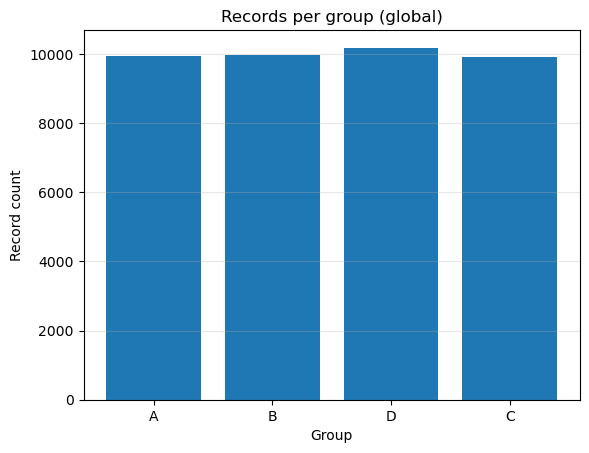

In [11]:
plt.style.use("default")

if PLOT_GROUP_COUNTS_BAR and group_counts:
    plt.figure()
    groups = list(group_counts.keys())
    counts = [group_counts[g] for g in groups]
    plt.bar(groups, counts)
    plt.xlabel("Group")
    plt.ylabel("Record count")
    plt.title("Records per group (global)")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()
